In [70]:
import json 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [71]:
def world_to_view(coord, frames, E, H, W):
    coord = np.array(coord + [1])  # Homogeneous coordinates
    coord_local = E @ coord
    z = coord_local[-2] * -1  # camera looks down -Z
    f = [- (v / (v[-1] / z)) for v in frames]
    min_x, max_x = f[2][0], f[1][0]
    min_y, max_y = f[1][1], f[0][1]
    x = (coord_local[0] - min_x) / (max_x - min_x)
    y = (coord_local[1] - min_y) / (max_y - min_y)
    u = x * W
    v = (1 - y) * H
    return u, v, z

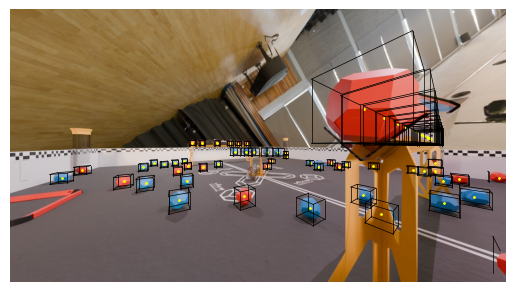

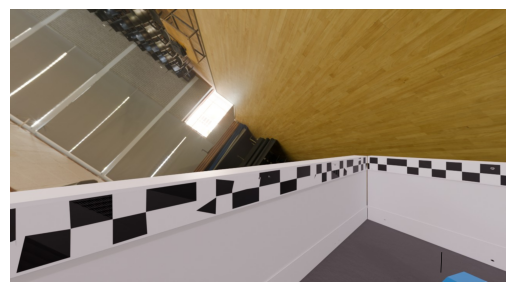

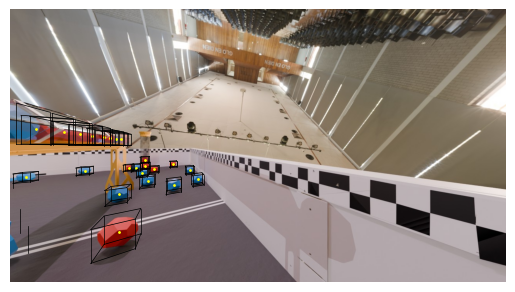

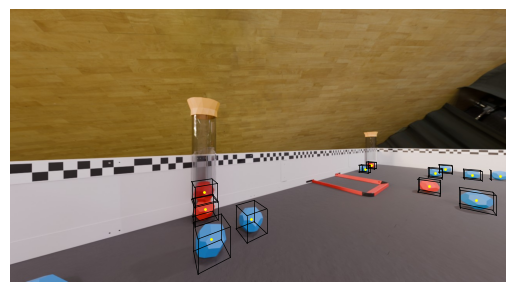

In [72]:
H, W = 704, 1280
idx = 1
with open(f'renders/gpu_0/scene_{idx}/capture_meta.json', 'r') as f:
    capture_metadata = json.load(f)
with open(f'renders/gpu_0/scene_{idx}/field_metadata.json', 'r') as f:
    field_metadata = json.load(f)
for cam_meta in sorted(capture_metadata['cameras'], key=lambda x: x['name']):
    cam_name = cam_meta['name']
    E = np.array(cam_meta['extrinsic_matrix'])
    frames = [np.array(vf) for vf in cam_meta['view_frame'][:3]]
    image = np.array(Image.open(f'renders/gpu_0/scene_{idx}/{cam_name}.jpg'))
    plt.imshow(image)
    plt.axis('off')
    for block_meta in field_metadata['blocks']:
        block_loc, block_dim = block_meta['location'], block_meta['dimensions']
        bounding_box_loc = [
            [block_loc[0] - block_dim[0]/2, block_loc[1] - block_dim[1]/2, block_loc[2] - block_dim[2]/2],
            [block_loc[0] + block_dim[0]/2, block_loc[1] - block_dim[1]/2, block_loc[2] - block_dim[2]/2],
            [block_loc[0] - block_dim[0]/2, block_loc[1] + block_dim[1]/2, block_loc[2] - block_dim[2]/2],
            [block_loc[0] + block_dim[0]/2, block_loc[1] + block_dim[1]/2, block_loc[2] - block_dim[2]/2],
            [block_loc[0] - block_dim[0]/2, block_loc[1] - block_dim[1]/2, block_loc[2] + block_dim[2]/2],
            [block_loc[0] + block_dim[0]/2, block_loc[1] - block_dim[1]/2, block_loc[2] + block_dim[2]/2],
            [block_loc[0] - block_dim[0]/2, block_loc[1] + block_dim[1]/2, block_loc[2] + block_dim[2]/2],
            [block_loc[0] + block_dim[0]/2, block_loc[1] + block_dim[1]/2, block_loc[2] + block_dim[2]/2],
        ]
        center_u, center_v, center_z = world_to_view(block_loc, frames, E, H, W)
        if center_z > 0 and 0 <= center_u < W and 0 <= center_v < H:
            plt.scatter(center_u, center_v, c='yellow', s=1)
        aabb = []
        mask = []
        for corner in bounding_box_loc:
            u, v, z = world_to_view(corner, frames, E, H, W)
            aabb.append((u, v, z))
            mask.append(z > 0 and 0 <= u < W and 0 <= v < H)
        # plot bounding box of all corners if they are visible
        for i in range(8):
            for j in range(i + 1, 8):
                # check if i and j differ by only one bit
                if bin(i ^ j).count('1') == 1:
                    if mask[i] and mask[j]:
                        plt.plot([aabb[i][0], aabb[j][0]], [aabb[i][1], aabb[j][1]], c='black', linewidth=0.5)
    plt.show()
        
        
        
